#### Teoría de Circuitos II - UTN.BA

# Tarea Semanal 4
#### Autor: Rodríguez Silvosa, Martín
#### Docentes: LLamedo, Mariano ; Moharos, David

### Consigna:
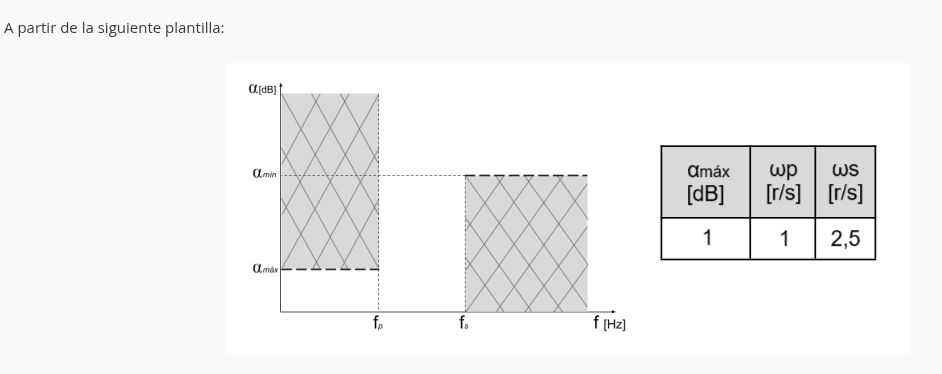

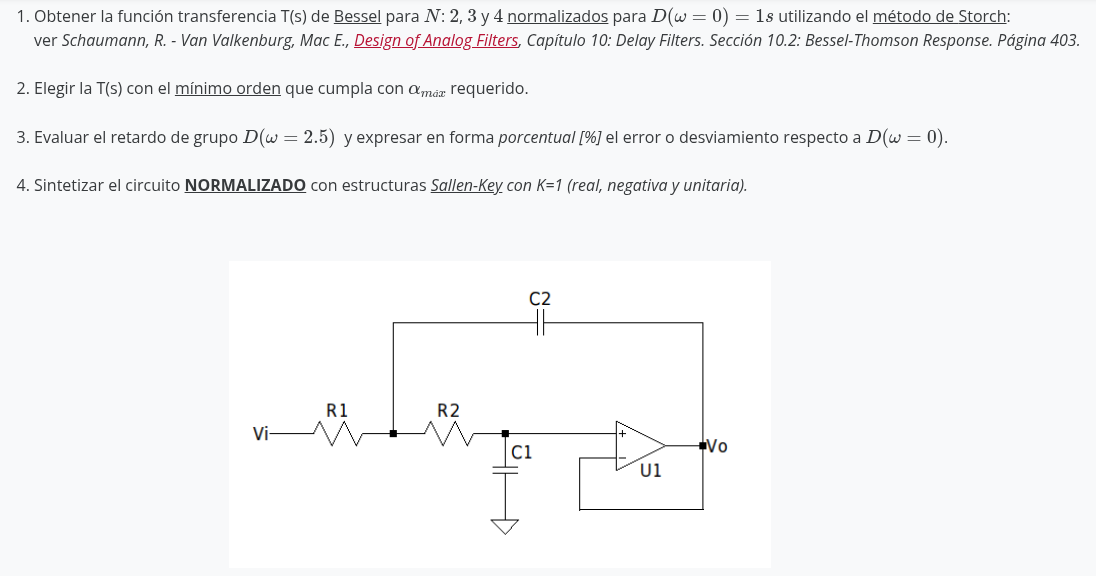

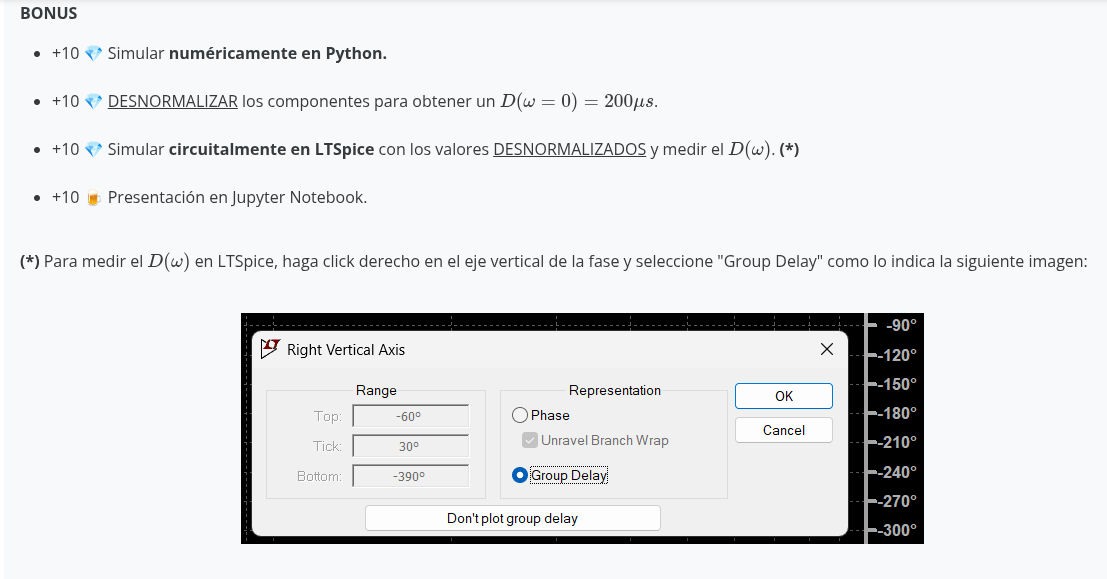

### Aproximación Bessel:

$$
T(S) \propto \frac{1}{e^{S}} = \frac{1}{cosh(S) + senh(S)} = \frac{ \frac{1}{senh(S)} }{ \frac{ cosh(S) }{ senh(S) } + 1}
$$
#### donde podemos sustituir dependiendo del orden n las aproximaciones polinómicas:
$$
\left. senh(S) \right|_n = S + \frac{S^3}{3!} + \frac{S^5}{5!} + \  ...
$$

$$
\left. cosh(S) \right|_n = 1 + \frac{S^2}{2!} + \frac{S^4}{4!} + \  ...
$$

$$
\left. cotgh(S) \right|_n = \frac{cosh(S)}{senh(S)}= \frac{1}{S} + \frac{1}{ \frac{3}{S} + \frac{1}{ \frac{5}{S} + \frac{1}{ \frac{7}{S} + \ ... }} } = \frac{par(S)}{impar(S)}
$$
#### Quedándonos entonces el denominador de la transferencia como:
$$
T(S) = \frac{a_0}{par(S) + impar(S)}
$$
#### E igualaremos el nominador de la transferencia al término independiente para cumplir $D(\omega = 0) = 1s$

### De esta forma, nos quedarán entonces 3 transferencias dependiendo de n:

#### n = 2:
$$
\frac{cosh(S)}{senh(S)} = \frac{S^2 + 3}{3S} \rightarrow T(S) = \frac{3}{S^2 + 3S + 3}
$$

#### n = 3:
$$
\frac{cosh(S)}{senh(S)} = \frac{6S^2 + 15}{S^3 + 15S} \rightarrow T(S) = \frac{15}{S^3 + 6S^2 + 15S + 15}
$$

#### n = 4:
$$
\frac{cosh(S)}{senh(S)} = \frac{S^4 + 45S^2 + 105}{10S^3 + 105S} \rightarrow T(S) = \frac{105}{S^4 + 10S^3 + 45S^2 + 105S + 105}
$$

### Veremos el mínimo orden que cumple la plantilla:
$$
\alpha_{max}[dB] = 1 = \left. 10 \cdot log\left(\frac{\left| par(j\omega) + impar(j\omega) \right|^2}{a_0^2}\right) \right|_{\omega = 1}
$$

$$
llamaremos \ \left| par(j\omega) + impar(j\omega) \right|^2 = \left| B_n(j\omega) \right|^2
$$
#### n = 2:
$$
\left| B_2(j\omega) \right|^2 = \omega^4 + 3\omega^2 + 9
$$

$$
\alpha_{max}[dB] = 10 \cdot log \left( \frac{1 + 3 + 9}{9} \right) \approx 1.597dB \rightarrow no \ cumple \ plantilla.
$$
#### n = 3:
$$
B_3(j\omega) = (15 - 6\omega^2) + j (15\omega - \omega^3)
$$

$$
\left| B_3(j\omega) \right|^2 = \omega^6 + 6\omega^4 + 45\omega^2 + 225
$$

$$
\alpha_{max}[dB] = 10 \cdot log \left( \frac{1 + 6 + 45 + 225}{225} \right) \approx 0.9029dB \rightarrow cumple.
$$
### Nos queda entonces que $n=3$ es el mínimo orden requerido para cumplir el requerimiento de la plantilla

## Evaluación retardo de grupo:
#### Tendremos que:
$$
D(\omega) = - \frac{\delta \theta}{\delta \omega}
$$

$$
\theta(\omega) = - {tg}^{-1} \left( \frac{Im}{Re} \right)
$$

$$
B_3(j\omega) = Re + j \ Im
$$

#### Mediante una equivalencia algebraica, nos queda que:
$$
D(\omega) = \frac{{Im}^{'} \cdot Re - Im \cdot {Re}^{'}}{{Re}^2 + {Im}^2}
$$

#### Recordemos $B_3(j\omega) = (15 - 6\omega^2) + j (15\omega - \omega^3)$:
#### Derivando respecto a $\omega$ nos queda entonces:
$$
{Re}^{'} = -12\omega \ \ \ \ \& \& \ \ \ \ {Im}^{'} = 15 -3\omega^2 
$$

#### Sustituyendo, expandiendo y simplificando la ecuación nos queda:
$$
D(\omega) = \frac{6\omega^4 + 45 \omega^2 + 225}{\omega^6 + 6\omega^4 + 45\omega^2 + 225}
$$

#### Evaluamos para $\omega = 0$:
$$
D(0) = \frac{225}{225} = 1_{seg} 
$$

#### Evaluamos para $\omega_s = 2.5$:
$$
D({2.5}) = \frac{6 \cdot {2.5}^4 + 45 \cdot {2.5}^2 + 225}{{2.5}^6 + 6 \cdot {2.5}^4 + 45 \cdot {2.5}^2 + 225} = \frac{1896}{2521} \approx 0.7521_{seg} 
$$

### Error o desviamiento porcentual respecto $D(\omega = 0)$ :
$$
Error [\%] = \frac{D(2.5) - D(0)}{D(0)} \cdot 100
$$

$$
Error [\%] = \frac{0.7521 - 1}{1} \cdot 100 = -24.79 \%
$$


#### Importación de librerías a usar:

In [1]:
import sympy as sp
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
import math

## Simulaciones Transferencia y retardo en Python:

Retardo en w=0: 1.0000 s
Retardo en w=2.5: 0.7513 s
Desviación porcentual simulada: -24.87%


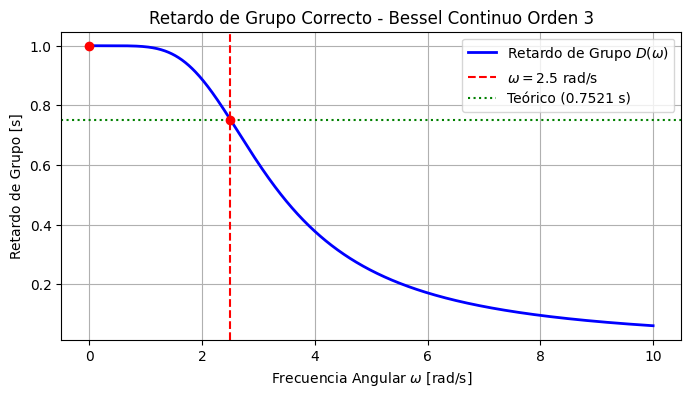

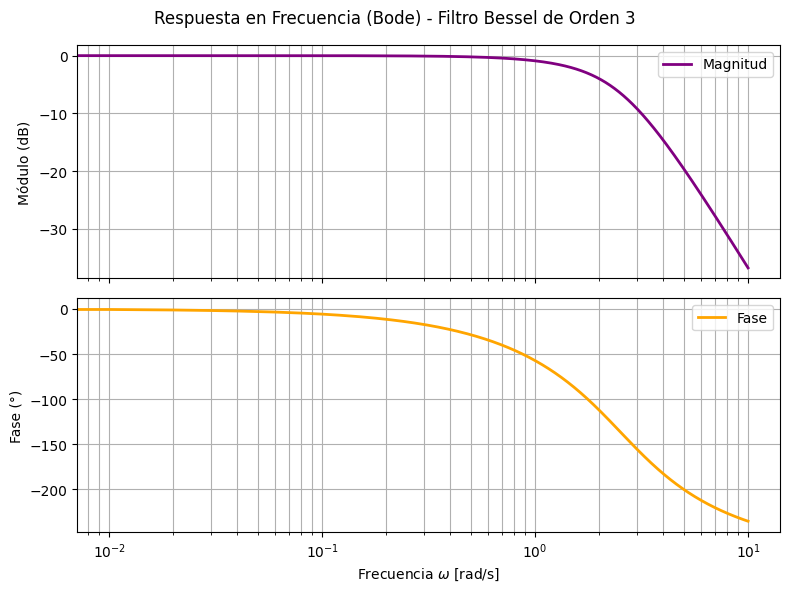

In [7]:
# 1. Definimos la transferencia (Bessel orden 3)
num = [15]
den = [1, 6, 15, 15]
H = sig.TransferFunction(num, den)

# 2. Generamos el vector de frecuencias angulares (omega)
w = np.linspace(0, 10, 1000)

# 3. Calculamos la respuesta en frecuencia
w_out, H_freq = sig.freqs(num, den, worN=w)

# 4. Calculamos el RETARDO DE GRUPO
# Primero se extrae la fase desplegada (unwrapped) en radianes
fase_rad = np.unwrap(np.angle(H_freq))
# Luego aproximamos la derivada -d(fase)/dw mediante diferencias centrales de la pendiente
gd = -np.gradient(fase_rad, w)

# 5. Encontramos los valores para w = 0 y w = 2.5
idx_0 = np.argmin(np.abs(w - 0.0))
idx_25 = np.argmin(np.abs(w - 2.5))
gd_0 = gd[idx_0]
gd_25 = gd[idx_25]
error_porcentual = ((gd_25 - gd_0) / gd_0) * 100

print(f"Retardo en w=0: {gd_0:.4f} s")
print(f"Retardo en w=2.5: {gd_25:.4f} s")
print(f"Desviación porcentual simulada: {error_porcentual:.2f}%")

# 6. Graficar el Retardo de Grupo
plt.figure(figsize=(8, 4))
plt.plot(w, gd, label=r"Retardo de Grupo $D(\omega)$", color="blue", lw=2)
plt.axvline(2.5, color="red", linestyle="--", label=r"$\omega = 2.5$ rad/s")
plt.axhline(0.7521, color="green", linestyle=":", label="Teórico (0.7521 s)")
plt.scatter([0, 2.5], [gd_0, gd_25], color="red", zorder=5)
plt.title("Retardo de Grupo - Bessel Orden 3")
plt.xlabel("Frecuencia Angular $\omega$ [rad/s]")
plt.ylabel("Retardo de Grupo [s]")
plt.grid(True, which="both")
plt.legend()
plt.show()

# 7. Graficar Módulo y Fase (Bode) utilizando sig.bode
w_bode, H_mag, H_phase = sig.bode(H, w=w)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
fig.suptitle("Respuesta en Frecuencia (Bode) - Filtro Bessel de Orden 3")

ax1.semilogx(w_bode, H_mag, color="purple", lw=2, label="Magnitud")
ax1.set_ylabel("Módulo (dB)")
ax1.grid(True, which="both")
ax1.legend()

ax2.semilogx(w_bode, H_phase, color="orange", lw=2, label="Fase")
ax2.set_ylabel("Fase (°)")
ax2.set_xlabel("Frecuencia $\omega$ [rad/s]")
ax2.grid(True, which="both")
ax2.legend()

plt.tight_layout()
plt.show()

## Síntesis del circuito normalizado:
### Utilizaremos El Sallen-Key y 1 filtro pasivo para el polo restante (transferencia orden 3):
#### Transferencia Sallen-Key:

In [10]:
# Parámetros:
Y1, Y2, Y3, Y4, Y5, Y6 = sp.symbols("Y1, Y2, Y3, Y4, Y5, Y6")
V1, V2, V3, V4 = sp.symbols("V1, V2, V3, V4")
G1, G2, G3, G4, C1, C2, wt, w0 = sp.symbols("G1, G2, G3, G4, C1, C2, wt, w0", real=True, positive=True) 
s = sp.symbols('s')

eq1 = V3*(Y1+Y2+Y6) - V1*Y1 - V2*Y6 - V4*Y2
eq2 = V4*(Y4+Y3) - V2*Y4
eq3 = V4*(Y5+Y2) - V3*Y2

# 1: Resolver los nodos internos V3 y V4 en función de V1 y V2
solucion = sp.solve([eq1, eq2, eq3], [V2, V3, V4], dict=True)

# Extraemos la solución del primer (y único) diccionario de la lista
# Buscamos V2, que estará expresado en función de V1
V2_resuelto = solucion[0][V2]

# Calculamos la transferencia T = V2 / V1
T = sp.simplify(V2_resuelto / V1)

# Impresión en formato original (Admitancias)
print_latex(a_equal_b_latex_s('T(s)', T))

# Sustitución de componentes analógicos
T_s = T.subs({
    Y1: G1,
    Y2: G2,
    Y3: G3,
    Y4: G4,
    Y5: s*C1,
    Y6: s*C2
})

# Tus bloques de simplificación originales
T_s = sp.together(T_s)
T_s = sp.factor(T_s)
T_s = sp.simplify(T_s)

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Considerando $\frac{G3+G4}{G4}$ como la ganancia del amplificador no inversor, dejando mónico el sistema nos queda:
$$
T(s) = \frac{G3+G4}{G4} \cdot \frac{ \frac{G1G2}{C1C2} }{s^2 + s \cdot \left( \frac{G1}{C2} + \frac{G2}{C2} - \frac{G2G3}{C1G4} \right) + \frac{G1G2}{C1C2}}
$$
#### Ahora considerando ganancia unitaria $\rightarrow G3=0$:
$$
T(s) = \frac{ \frac{G1G2}{C1C2} }{s^2 + s \cdot \left( \frac{G1}{C2} + \frac{G2}{C2}\right) + \frac{G1G2}{C1C2}}
$$

#### Recordemos transferencia a sintetizar:
$$
T(S) = \frac{15}{S^3 + 6S^2 + 15S + 15}
$$
#### Fraccionando la transferencia en 2 secciones, se puede comprobar que nos queda:
$$
T(S) = \frac{2.322}{S+2.322} \cdot \frac{2.54^2}{S^2 + S \cdot \frac{2.54}{0.69} + 2.54^2}
$$
#### Igualando la sección de segundo orden a la Sallen-key nos queda:
$$
\frac{G1G2}{C1C2} = 2.54^2
$$

$$
\frac{G1}{C2} + \frac{G2}{C2}=\frac{2.54}{0.69}
$$

#### Y para el polo restante:
$$
T_1(S) = \frac{2.322}{S+2.322} = \frac{\frac{1}{RaCa}}{S+ \frac{1}{RaCa}}
$$

$$
2.322 = \frac{1}{RaCa}
$$

#### Reestricciones para la síntesis:
$$
Ra = 1 \rightarrow \frac{1}{1 \cdot Ca} = 2.322 \rightarrow Ca = 0.4306
$$

$$
R1 = R2 = 1:
$$
$$
\frac{2}{C2} = \frac{2.54}{0.69} \rightarrow C2 = 0.5433
$$
$$
2.54^2 = \frac{1}{C1C2} \rightarrow C1 = 0.28529
$$

### Simulación normalizada:

#### Recordemos simulación en Hz:

$$
\omega_c = 1 = 2\pi f \rightarrow f = \frac{1}{2\pi} = 159.154mHz
$$

$$
\omega_s = 2.5 = 2\pi f \rightarrow f = \frac{2.5}{2\pi} = 397.887mHz
$$

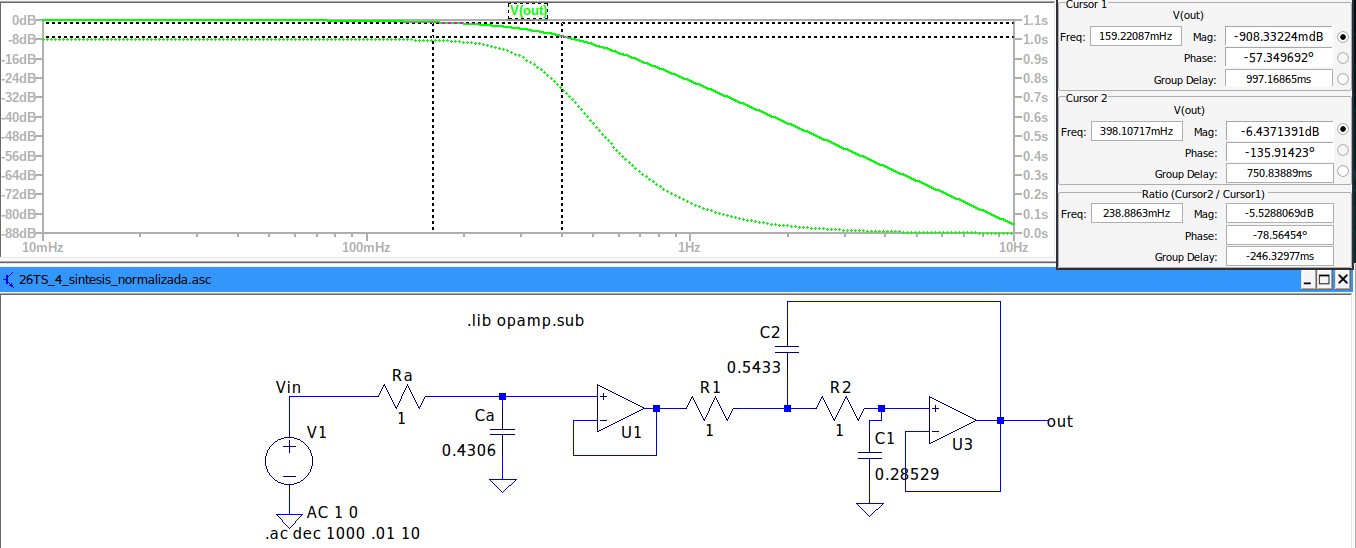

### Desnormalización:

#### El objetivo de $D(\omega = 0) = 200_{useg}$ nos brinda con la norma de frecuencia de la siguiente manera:

$$
\Omega_\omega = \frac{D_{normalizado} (\omega = 0)}{D_{objetivo} (\omega = 0)} = \frac{1_{seg}}{200_{useg}} = 5000 \frac{rad}{seg}
$$

#### Norma de impedancia arbitraria y simple:
$$
\Omega_z = 10000
$$

#### Reemplazando sobre los componentes nos queda:
$$
Ra = 1 \cdot 10000 = 10000 \ \Omega
$$

$$
Ca = \frac{0.4306}{5000 \cdot 10000} = 8.612 \ nF
$$

$$
R1 = R2 = Ra = 10 \ K\Omega
$$

$$
C2 = \frac{0.5433}{5000 \cdot 10000} = 10.866 \ nF
$$

$$
C1 = \frac{0.28529}{5000 \cdot 10000} = 5.7058 \ nF
$$

### Simulación en LTSpice:
#### Recordemos:
$$
\omega_0 = 5000 \frac{rad}{seg} \rightarrow f_0 = 795.775 Hz
$$

$$
\omega_s = 2.5 \cdot 5000 \frac{rad}{seg} \rightarrow f_s = 1989.437 Hz
$$

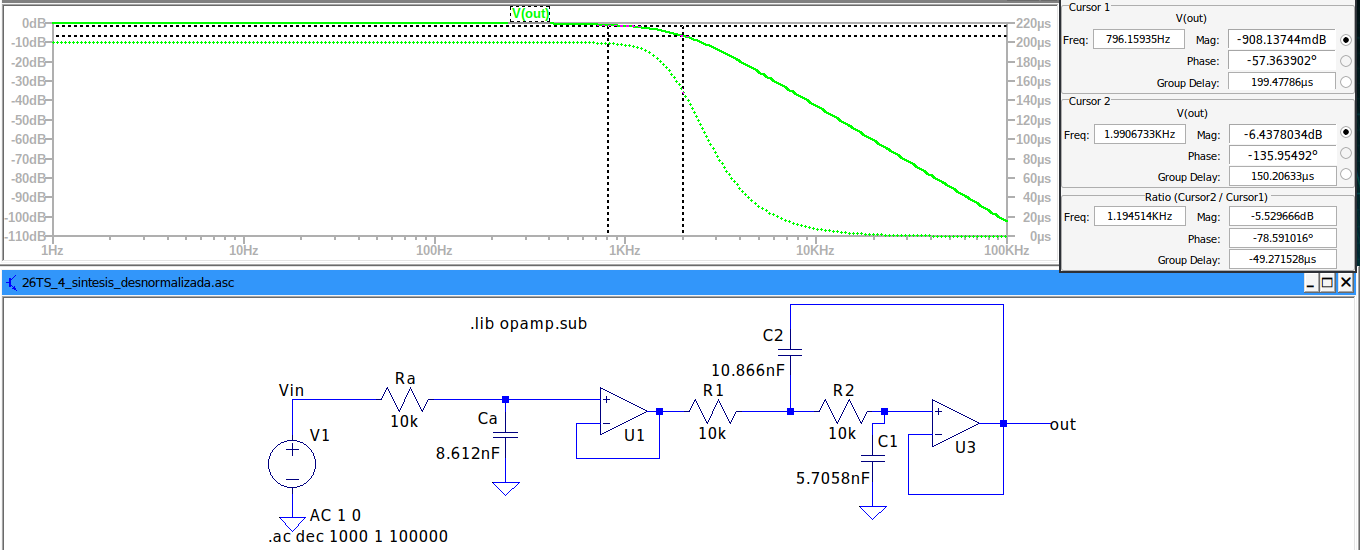

#### Las simulaciones normalizadas y desnormalizadas cumplen con las especificaciones de la plantilla objetivo